## fmuritalKNN.ipynb
## Supervised Learning: K-Nearest Neighbor Classification
## Use Case: Sentiment Analysis of Movie Reviews
## Faruk Muritala
## Oct 1 2023

In [ ]:
# Section 1: Import the 'getpass' function from the 'getpass' module to securely input sensitive information like API tokens

from getpass import getpass


In [ ]:
# Section 2: Import OS and Install Necessary Packages

# Import the 'os' module to interact with the operating system
import os

# Import the 'numpy' library for numerical operations
import numpy as np

# Install necessary packages using pip
# - 'langchain' for language processing
# - 'sentence_transformers' for working with sentence embeddings
# - 'chromadb' for working with vector stores
# - 'transformers', 'sentencepiece', and 'sacremoses' for language model support
!pip install langchain
!pip install sentence_transformers
!pip install chromadb
!pip install transformers sentencepiece sacremoses
!pip install -q transformers
!pip install -q simpletransformers
!pip install -q datasets



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 26.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 25.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 93.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.1 MB/s eta 0:00:00
  Created wheel for sentence_transformers: filename=sentence_transformers-2.2.2-py3-none-any.whl size=125923 sha256=41bb2fadff533b78b3f1b816406f64c9c37515073aed029435c4c5dbbbeed452
  Stored in directory: /root/.cache/pip/wheels/62/f2/10/1e606fd5f02395388f74e7462910fe851042f97238cbbd902f
Successfully built sentence_transfo

In [ ]:
# Section 3: Import Libraries and Modules for Text Processing and Analysis

# Import necessary modules and classes for text processing and analysis
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.document_loaders import WebBaseLoader
from langchain import HuggingFaceHub
from langchain import PromptTemplate, LLMChain
from langchain.indexes import VectorstoreIndexCreator
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from collections import Counter


In [ ]:
# Section 4: Set Up API Token

# Prompt the user to securely input their Hugging Face API token using 'getpass'
HUGGINGFACEHUG_API_TOKEN = getpass()

# Set the API token in the environment variable for later use
os.environ["HUGGINGFACEHUG_API_TOKEN"] = HUGGINGFACEHUG_API_TOKEN


··········


In [ ]:
# Install the "datasets" Python package
#!pip install datasets

# Import NumPy and alias it as "np"
import numpy as np
# Import Pandas and alias it as "pd"
import pandas as pd
# Import the "load_dataset" function from the "datasets" package
from datasets import load_dataset

# Load IMDb training data
dataset_train = load_dataset('imdb', split='train')
# Rename the 'label' column to 'labels' in training data
dataset_train = dataset_train.rename_column('label', 'labels')
# Convert training data to a Pandas DataFrame
train_df = pd.DataFrame(dataset_train)

# Load IMDb testing data
dataset_test = load_dataset('imdb', split='test')
# Rename the 'label' column to 'labels' in testing data
dataset_test = dataset_test.rename_column('label', 'labels')

# Convert testing data to a Pandas DataFrame
test_df = pd.DataFrame(dataset_test)


Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
# Create a list containing the training and testing DataFrames
dfs = [train_df, test_df]

# Concatenate (combine) the DataFrames vertically to create a single dataset
total_dataset = pd.concat(dfs)

# Display the first few rows of the combined dataset
total_dataset.head()

# Calculate and display the length (number of rows) of the combined dataset
len(total_dataset)



50000

In [ ]:
# Import the DataFrameLoader class from the "langchain.document_loaders" module
from langchain.document_loaders import DataFrameLoader

# Create an instance of the DataFrameLoader class with the combined dataset
# Specify the 'text' column as the page content column
loader = DataFrameLoader(total_dataset, page_content_column='text')

# Load data using the DataFrameLoader instance and store it in the 'data' variable
data = loader.load()


In [ ]:
Practice_data = data[::25][:1500]
#FOR PRACTICE I FIRST USE 1,500 TO SET THE ALGORITHM IN A SYSTEMATIC WAY (TAKING 25TH POINT)
Practice_data

In [ ]:
# Section 7: Vectorstore Creation

# Step 5: Vectorstore Creation
# Note: If using the OpenAIEmbeddings, change embedding to OpenAIEmbeddings in the Vector store
# from langchain.embeddings import OpenAIEmbeddings

# Create a list of IDs for the documents

#ids = [str(i) for i in range(1, len(Practice_data) + 1)]

ids = [str(i + 1) for i in range(len(Practice_data))]


# Create a Chroma vector store from the preprocessed text segments using HuggingFaceEmbeddings
vectorstore = Chroma.from_documents(documents=Practice_data, embedding=HuggingFaceEmbeddings(), ids=ids)


In [ ]:
# Section 8: Checking Individual IDs and Result

# Checking for individual IDs
# You can uncomment and use this line to check a specific ID's embeddings, documents, and metadata.
# print(vectorstore._collection.get(ids=[ids[20]], include=['embeddings', 'documents', 'metadatas']))

# Retrieving all results including embeddings, documents, and metadata
result = vectorstore._collection.get(include=['embeddings', 'documents', 'metadatas'])
#result = vectorstore

In [ ]:
#result["metadatas"]

In [ ]:
# Create a DataFrame containing embeddings and metadatas from the vectorstore
embframe = pd.DataFrame(vectorstore._collection.get(include=["embeddings", "metadatas"]))

# Extract the 'labels' from the 'metadatas' in embframe and store them in a list
labels = [x['labels'] for x in embframe['metadatas']]

# Create a DataFrame from the extracted 'labels'
labeling = pd.DataFrame(labels)


In [ ]:
# Add a new column "labeling" to the "embframe" DataFrame and assign the "labeling" values to it
embframe["labeling"] = labeling

# Display the updated "embframe" DataFrame
embframe


,ids,embeddings,metadatas,documents,labeling
0,1,"[0.051543161273002625, 0.0489380918443203, -0....",{'labels': 0},None,0
1,2,"[0.03632645308971405, 0.07537887990474701, 0.0...",{'labels': 0},None,0
2,3,"[-0.014511918649077415, 0.05494450032711029, 0...",{'labels': 0},None,0
3,4,"[-0.01970786042511463, 0.033430349081754684, -...",{'labels': 0},None,0
4,5,"[0.07153258472681046, -0.01917363330721855, -0...",{'labels': 0},None,0
...,...,...,...,...,...
1495,1496,"[0.005643482320010662, 0.041358333081007004, -...",{'labels': 0},None,0
1496,1497,"[0.0016696370439603925, 0.07548338174819946, -...",{'labels': 0},None,0
1497,1498,"[0.027311252430081367, 0.03860011324286461, 0....",{'labels': 0},None,0
1498,1499,"[0.011615767143666744, -0.03275727108120918, 0...",{'labels': 0},None,0


In [ ]:

from sklearn.model_selection import train_test_split

# Assuming you have your data and target variables named 'X' and 'y'
# X is your data, and y is your target (labels or values to predict)
X = embframe["embeddings"]
y = embframe["labeling"]

# Split the data into 70% training and 30% testing
train_size = 0.7  # Specify the training set size (70% in this case)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=(1 - train_size), random_state=42)

# 'test_size' specifies the size of the testing set (in this case, 30%)
# 'random_state' is a seed for the random number generator to ensure reproducibility



In [ ]:

def calculate_euclidean_distance(point1, point2):
    # Calculate the Euclidean distance between two points: point1 and point2
    distance = np.sqrt(np.sum((point1 - point2)**2))
    return distance

class KNearestNeighborsClassifier:
    def __init__(self, n_neighbors=3):
        # Initialize the K-Nearest Neighbors classifier with a default value of n_neighbors as 3
        self.n_neighbors = n_neighbors

    def fit(self, X_train, y_train):
        # Store the training data (features X_train) and labels (y_train) within the classifier
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        # Make predictions for a set of test data points (X_test)
        # by calling the private method _predict for each data point in X_test
        predictions = [self._predict(data_point) for data_point in X_test]
        return predictions

    def _predict(self, data_point):
        # Private method to predict the label for a single data point (data_point)
        # - Compute the distance between data_point and all training data points
        # - Find the indices of the n_neighbors nearest neighbors
        # - Count the majority label among the n_neighbors nearest neighbors
        # - Return the predicted label
        distances = [calculate_euclidean_distance(data_point, train_point) for train_point in self.X_train]
        nearest_neighbor_indices = np.argsort(distances)[:self.n_neighbors]
        nearest_neighbor_labels = [self.y_train[i] for i in nearest_neighbor_indices]
        most_common_label = Counter(nearest_neighbor_labels).most_common(1)
        return most_common_label[0][0]


In [ ]:

# Assuming X&y_train and X&y_test are lists of data points

#np.array(list(result['embeddings']))
# Convert the 'train' and 'test' list of data points into a NumPy array

X_train = np.array(list(X_train))
y_train = np.array(list(y_train))

X_test = np.array(list(X_test))
y_test = np.array(list(y_test))



In [ ]:
# Implementing the K-Nearest Neighbors Classifier
# Create an instance of the K-Nearest Neighbors (KNN) classifier with 5 neighbors
knn_classifier = KNearestNeighborsClassifier(n_neighbors=5)

# Fit the KNN classifier to the training data
knn_classifier.fit(X_train, y_train)

# Predict labels for the test data using the trained KNN classifier
predicted_labels = knn_classifier.predict(X_test)

# Print the predicted labels
print(predicted_labels)


[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
# Calculate accuracy

# Calculate accuracy by comparing predicted labels to true labels
accuracy = np.sum(predicted_labels == y_test) / len(y_test)
# Count the number of true positive predictions
number_of_true_positive = np.sum(predicted_labels == y_test)
# Count the number of false positive predictions
number_of_false_positive = np.sum(predicted_labels != y_test)


# Print the test size (number of test samples)
print("Test size: ", len(y_test))
# Print the number of false positive predictions
print("Number of False Positive: ", number_of_false_positive)
# Print the number of true positive predictions
print("Number of True Positive: ", number_of_true_positive)
# Print the accuracy of the KNN classifier
print("Accuracy:", accuracy)


Test size:  451
Number of False Positive:  90
Number of True Positive:  361
Accuracy: 0.8004434589800443


In [ ]:
#Confusion Matrix and Accuracy:

from sklearn.metrics import confusion_matrix, accuracy_score

# Calculate the confusion matrix
confusion = confusion_matrix(y_test, predicted_labels)

# Calculate accuracy
accuracy = accuracy_score(y_test, predicted_labels)

print("Confusion Matrix:\n", confusion)
print("Accuracy:", accuracy)


Confusion Matrix:
 [[298  12]
 [ 78  63]]
Accuracy: 0.8004434589800443


In [ ]:
# Examples of Correct and Incorrect Classification

# Create a dictionary to map vectorstore IDs to their corresponding Practice_data entries
id_to_data = {}

for idx in range(len(Practice_data)):
    vectorstore_id = ids[idx]  # Get the vectorstore ID
    data_point = Practice_data[idx]  # Get the corresponding Practice_data entry
    id_to_data[vectorstore_id] = data_point

# Initialize lists for correct and incorrect classifications
correct_positives = []
correct_negatives = []
incorrect_positives = []
incorrect_negatives = []

for idx in range(len(y_test)):
    predicted_label = predicted_labels[idx]
    actual_label = y_test[idx]
    vectorstore_id = ids[idx]  # Get the vectorstore ID

    # Get the corresponding Practice_data entry using the dictionary
    data_point = id_to_data.get(vectorstore_id)

    if data_point is not None:
        if predicted_label == actual_label:
            if predicted_label == 1:  # Correct positive classification
                correct_positives.append(data_point)
            else:  # Correct negative classification
                correct_negatives.append(data_point)
        else:
            if predicted_label == 1:  # Incorrect positive classification
                incorrect_positives.append(data_point)
            else:  # Incorrect negative classification
                incorrect_negatives.append(data_point)

print("Samples of Correct Positive Classification:")
for sample in correct_positives[:3]:
    print(sample)

print("Samples of Correct Negative Classification:")
for sample in correct_negatives[:3]:
    print(sample)

print("Samples of Incorrect Positive Classification:")
for sample in incorrect_positives[:3]:
    print(sample)

print("Samples of Incorrect Negative Classification:")
for sample in incorrect_negatives[:3]:
    print(sample)


Samples of Correct Positive Classification:
page_content='I saw the capsule comment said "great acting." In my opinion, these are two great actors giving horrible performances, and with zero chemistry with one another, for a great director in his all-time worst effort. Robert De Niro has to be the most ingenious and insightful illiterate of all time. Jane Fonda\'s performance uncomfortably drifts all over the map as she clearly has no handle on this character, mostly because the character is so poorly written. Molasses-like would be too swift an adjective for this film\'s excruciating pacing. Although the film\'s intent is to be an uplifting story of curing illiteracy, watching it is a true "bummer." I give it 1 out of 10, truly one of the worst 20 movies for its budget level that I have ever seen.' metadata={'labels': 0}
page_content="This was a movie i could not wait to see! So i finally got it and I was pretty disappointed. For starters,the movie has so little said about New York,ju

In [ ]:
# Examples of Correct Classification:
correctly_classified_indices = np.where(predicted_labels == y_test)[0]
incorrectly_classified_indices = np.where(predicted_labels != y_test)[0]

print("Examples of Correct Classification:")
for idx in correctly_classified_indices[:3]:
    predicted_label = predicted_labels[idx]
    actual_label = y_test[idx]  # Access the label using NumPy array indexing
    print(f"Predicted: {predicted_label} | Actual: {actual_label}")

print("\nExamples of Incorrect Classification:")
for idx in incorrectly_classified_indices[:3]:
    predicted_label = predicted_labels[idx]
    actual_label = y_test[idx]  # Access the label using NumPy array indexing
    print(f"Predicted: {predicted_label} | Actual: {actual_label}")


Examples of Correct Classification:
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0

Examples of Incorrect Classification:
Predicted: 0 | Actual: 1
Predicted: 0 | Actual: 1
Predicted: 0 | Actual: 1


In [ ]:
# Find the indices where predicted labels match the true labels (correctly classified)
correctly_classified_indices = np.where(predicted_labels == y_test)[0]

# Find the indices where predicted labels do not match the true labels (incorrectly classified)
incorrectly_classified_indices = np.where(predicted_labels != y_test)[0]

# Print examples of correctly classified data
print("Examples of Correct Classification:")
for idx in correctly_classified_indices[:3]:
    # Get the predicted and actual labels using the indices
    predicted_label = predicted_labels[idx]
    actual_label = y_test[idx]
    print(f"Predicted: {predicted_label} | Actual: {actual_label}")

# Print examples of incorrectly classified data
print("\nExamples of Incorrect Classification:")
for idx in incorrectly_classified_indices[:3]:
    # Get the predicted and actual labels using the indices
    predicted_label = predicted_labels[idx]
    actual_label = y_test[idx]
    print(f"Predicted: {predicted_label} | Actual: {actual_label}")


Examples of Correct Classification:
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0

Examples of Incorrect Classification:
Predicted: 0 | Actual: 1
Predicted: 0 | Actual: 1
Predicted: 0 | Actual: 1


In [ ]:
# Define lists of values for k (number of neighbors) and m (fraction of training data to use)
k_values = [3, 7, 15]
m_values = [70, 80, 90]

# Loop through each combination of k and m
for k in k_values:
    for m in m_values:
        # Create a new instance of the KNN classifier with specified K (k) value
        knn_classifier = KNearestNeighborsClassifier(n_neighbors=k)

        # Subset the training data to use a fraction of it (M=m)
        X_train_subset = X_train[:int(m * len(X_train))]
        y_train_subset = y_train[:int(m * len(X_train))]

        # Fit the KNN classifier with the subset of training data
        knn_classifier.fit(X_train_subset, y_train_subset)

        # Use the trained KNN classifier to predict labels for the test data
        predicted_labels = knn_classifier.predict(X_test)

        # Calculate and print the confusion matrix and accuracy for K=k and M=m
        confusion = confusion_matrix(y_test, predicted_labels)
        accuracy = accuracy_score(y_test, predicted_labels)
        print(f"Confusion Matrix (K={k}, M={m}):\n", confusion)
        print(f"Accuracy (K={k}, M={m}):", accuracy)


Confusion Matrix (K=3, M=70):
 [[286  24]
 [ 78  63]]
Accuracy (K=3, M=70): 0.7738359201773836
Confusion Matrix (K=3, M=80):
 [[286  24]
 [ 78  63]]
Accuracy (K=3, M=80): 0.7738359201773836
Confusion Matrix (K=3, M=90):
 [[286  24]
 [ 78  63]]
Accuracy (K=3, M=90): 0.7738359201773836
Confusion Matrix (K=7, M=70):
 [[304   6]
 [ 84  57]]
Accuracy (K=7, M=70): 0.8004434589800443
Confusion Matrix (K=7, M=80):
 [[304   6]
 [ 84  57]]
Accuracy (K=7, M=80): 0.8004434589800443
Confusion Matrix (K=7, M=90):
 [[304   6]
 [ 84  57]]
Accuracy (K=7, M=90): 0.8004434589800443
Confusion Matrix (K=15, M=70):
 [[307   3]
 [ 92  49]]
Accuracy (K=15, M=70): 0.7893569844789357
Confusion Matrix (K=15, M=80):
 [[307   3]
 [ 92  49]]
Accuracy (K=15, M=80): 0.7893569844789357
Confusion Matrix (K=15, M=90):
 [[307   3]
 [ 92  49]]
Accuracy (K=15, M=90): 0.7893569844789357


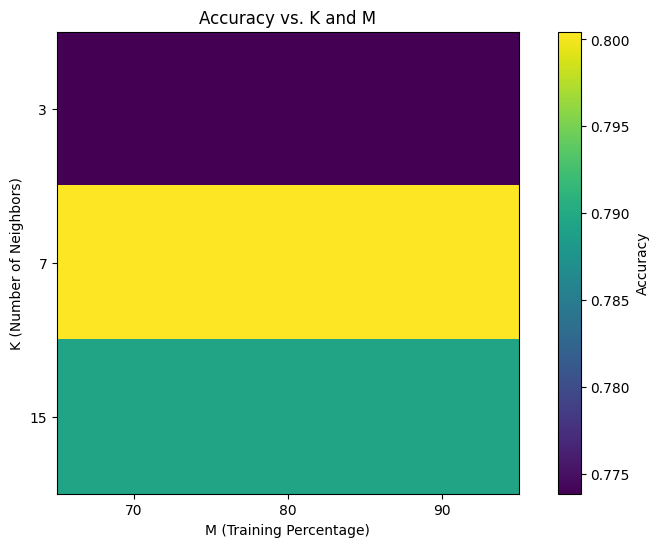

Optimum K: 7.0
Optimum M: 70.0


In [ ]:
# Import the matplotlib.pyplot library and alias it as "plt"
import matplotlib.pyplot as plt

# Define lists of values for k (number of neighbors) and m (fraction of training data to use)
k_values = [3, 7, 15]
m_values = [70, 80, 90]

# Create an empty list to store accuracy values
accuracies = []

# Loop through each combination of k and m
for k in k_values:
    for m in m_values:
        # Create a new instance of the KNN classifier with specified K (k) value
        knn_classifier = KNearestNeighborsClassifier(n_neighbors=k)

        # Subset the training data to use a fraction of it (M=m)
        X_train_subset = X_train[:int(m * len(X_train))]
        y_train_subset = y_train[:int(m * len(X_train))]

        # Fit the KNN classifier with the subset of training data
        knn_classifier.fit(X_train_subset, y_train_subset)

        # Use the trained KNN classifier to predict labels for the test data
        predicted_labels = knn_classifier.predict(X_test)

        # Calculate accuracy for K=k and M=m and store it in the accuracies list
        accuracy = accuracy_score(y_test, predicted_labels)
        accuracies.append((k, m, accuracy))

# Create a data frame for plotting
df_accuracy = pd.DataFrame(accuracies, columns=["K", "M", "Accuracy"])

# Create a pivot table for plotting
pivot_accuracy = df_accuracy.pivot(index="K", columns="M", values="Accuracy")

# Plot accuracy vs. K and M using a heatmap
plt.figure(figsize=(10, 6))
plt.imshow(pivot_accuracy, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Accuracy')
plt.xticks(np.arange(len(m_values)), m_values)
plt.yticks(np.arange(len(k_values)), k_values)
plt.xlabel("M (Training Percentage)")
plt.ylabel("K (Number of Neighbors)")
plt.title("Accuracy vs. K and M")
plt.show()

# Identify the optimum K and M based on the plot
optimum_k = df_accuracy.loc[df_accuracy["Accuracy"].idxmax()]["K"]
optimum_m = df_accuracy.loc[df_accuracy["Accuracy"].idxmax()]["M"]
print("Optimum K:", optimum_k)
print("Optimum M:", optimum_m)
